##### Hybrid Lorentz-ParT Masked Autoencoder for JetClass: GSoC 2026 Implementation

A complete notebook implementation of a **hybrid ParT + Lorentz-aware** model for JetClass-like ROOT data with:
- masked autoencoder pretraining,
- supervised multi-class fine-tuning,
- optional mass regression,
- **attention-gated hybrid fusion** (proposed improvement),
- ablation-ready and interpretable diagnostics.


## SECTION 1 — INTRODUCTION

Jet/event classification is a core HEP problem: better discrimination means better sensitivity to rare physics and improved precision on known processes.

- **JetClass** provides realistic large-scale multi-class data for particle-cloud learning.
- **ParT** contributes set-based transformer modeling with pairwise interaction bias.
- **L-GATr** contributes Lorentz-aware reasoning and relativistic structure priors.
- Last year’s hybrid direction combined these ideas with masked reconstruction.

### Improvement in this notebook
We implement **attention-gated hybrid fusion** so the model learns whether to trust the ParT branch or the Lorentz-aware branch on each event/token, rather than relying on static fusion.

### Scope
This notebook includes:
- MAE-style masked pretraining,
- classification fine-tuning,
- optional mass regression,
- evaluation, ablations, and diagnostics.


## SECTION 2 — SETUP


In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


In [2]:
@dataclass
class Config:
    """Global notebook config."""
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 128
    NUM_CLASSES: int = 10

    BATCH_SIZE: int = 16
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 12
    FINETUNE_EPOCHS: int = 20
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-4
    MASK_RATIO: float = 0.4

    USE_AUX_MASS: bool = False
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
        'px','py','pz','E','pt','eta','phi','charge','valid_mask'
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta','lnkT','lnz','lnm2')
    SCALE_FEATURES: Tuple[str, ...] = ('charge',)

    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 4
    NUM_LAYERS_LORENTZ: int = 3
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.1
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
    EARLY_STOP_PATIENCE: int = 5
    SEED: int = 42

cfg = Config()
cfg

Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=128, NUM_CLASSES=10, BATCH_SIZE=16, NUM_WORKERS=0, PRETRAIN_EPOCHS=12, FINETUNE_EPOCHS=20, LEARNING_RATE=0.0002, WEIGHT_DECAY=0.0001, MASK_RATIO=0.4, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_SIZE_LIMIT=100000, ENFORCE_STRICT_100K_WHEN_AVAILABLE=True, SAMPLING_SEED=42, NUM_TRAIN_FILES=None, NUM_VAL_FILES=None, NUM_TEST_FILES=None, PER_PARTICLE_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'eta', 'phi', 'charge', 'valid_mask'), PAIRWISE_FEATURES=('lnDelta', 'lnkT', 'lnz', 'lnm2'), SCALE_FEATURES=('charge',), EMBED_DIM=128, NUM_HEADS=8, NUM_LAYERS_PART=4, NUM_LAYERS_LORENTZ=3, MLP_RATIO=4.0, DROPOUT=0.1, USE_TOKEN_GATE=True, USE_EVENT_GATE=True, W_RECO=1.0, W_CONS=0.2, W_CLASS=1.0, AUX_MASS_WEIGHT=0.2, GRAD_CLIP_NORM=1.0, EARLY_STOP_PATIENCE=5, SEED=42)

In [3]:
def seed_everything(seed: int = 42) -> None:
    """Set seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## SECTION 3 — DATA UNDERSTANDING


In [4]:
def resolve_data_root(user_path: str) -> Path:
    """Resolve data root robustly for notebook/project-root execution."""
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    """Recursively discover .root files."""
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    """Infer class from filename prefix."""
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [5]:
BRANCH_CANDIDATES = {
    'px': ['part_px','px','PFCands_px','particle_px'],
    'py': ['part_py','py','PFCands_py','particle_py'],
    'pz': ['part_pz','pz','PFCands_pz','particle_pz'],
    'E': ['part_energy','part_e','energy','E','PFCands_energy','particle_e'],
    'pt': ['part_pt','pt','PFCands_pt','particle_pt'],
    'eta': ['part_eta','eta','PFCands_eta','particle_eta'],
    'phi': ['part_phi','phi','PFCands_phi','particle_phi'],
    'charge': ['part_charge','charge','PFCands_charge','particle_charge'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    """Resolve semantic names to existing branches."""
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        print('Resolved map:', resolve_branches(branches, BRANCH_CANDIDATES))
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'eta': None, 'phi': None, 'charge': 'part_charge'}


## SECTION 4 — ROOT DATA LOADING


In [6]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Compute pseudorapidity robustly via clipped atanh(pz / |p|)."""
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    """Convert awkward jagged event arrays to float arrays safely."""
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    """Read one ROOT file into per-event particle arrays with schema fallback."""
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing required momentum branches in {file_path.name}; need either (px,py,pz) or (pt,eta,phi).')

        read_keys = [v for v in bm.values() if v is not None]
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        if bm['E'] is not None:
            EL = _safe_event_arrays(ak.to_list(arrs[bm['E']]))
        else:
            EL = [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]

        if bm['charge'] is not None:
            qL = _safe_event_arrays(ak.to_list(arrs[bm['charge']]))
        else:
            qL = [np.zeros_like(px, dtype=np.float32) for px in pxL]

        for px, py, pz, E, pt, eta, phi, q in zip(pxL, pyL, pzL, EL, ptL, etaL, phiL, qL):
            n = min(len(px), len(py), len(pz), len(E), len(pt), len(eta), len(phi), len(q))
            if n == 0:
                continue
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n], 'eta': eta[:n], 'phi': phi[:n],
                'charge': q[:n], 'valid_mask': np.ones(n, dtype=np.float32)
            })
    return events

def pad_event(ev: Dict[str,np.ndarray], max_particles: int, feat_order: Tuple[str,...]):
    """Pad/truncate event to fixed length and return (x,mask,p4)."""
    x = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4 = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(ev.get(name, np.zeros_like(ev['px'])), nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    """Invariant mass of event-level four-vector sum."""
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [7]:
class JetClassDataset(Dataset):
    """Padded JetClass dataset."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    """Fit scaler on selected valid train particle features only."""
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    """Apply scaler on selected valid particle features only."""
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

In [8]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    """Randomly sample events without replacement and preserve feature/label alignment.

    Returns:
        List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]]: Sampled event tuples.
    """
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    """Build DataLoaders from ROOT files, with synthetic fallback.

    For real ROOT data, this function:
    1) Loads event-level samples from selected files,
    2) Uses exactly SAMPLE_SIZE_LIMIT sampled events in strict mode,
    3) Splits sampled events into train/val/test as 80/10/10.

    Memory behavior:
    - Uses bounded online reservoir sampling with cap=SAMPLE_SIZE_LIMIT.
    """
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                    'eta': safe_eta(px, py, pz).astype(np.float32),
                    'phi': np.arctan2(py, px).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)
        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {'classes': cls, 'class_weights': class_weights}

## SECTION 5 — FEATURE ENGINEERING

Particle features include cartesian and cylindrical kinematics and simple identity-like channels:
- `px, py, pz, E`
- `pt, eta, phi`
- `charge`
- `valid_mask`

Pairwise ParT-style features implemented below:
- `ln(Delta)` angular separation,
- `ln(kT)` relative transverse scale,
- `ln(z)` momentum sharing,
- `ln(m^2)` pairwise invariant mass proxy.

Numerical safeguards (`eps`, clamping, NaN/Inf cleanup) are included.


In [9]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    """Normalize an angle difference to the [-pi, pi] range."""
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Compute ParT-inspired pairwise features [B,N,N,4] from raw four-vectors."""
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0)

## SECTION 6 — MASKED AUTOENCODER PRETRAINING DATA PIPELINE


In [10]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    """Randomly mask valid particles only. True = masked token."""
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_structured_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor, frac: float = 0.2) -> torch.Tensor:
    """Structured masking: mask highest-pt particles."""
    pt = x[...,4]
    B, N = pt.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * frac))
        order = torch.argsort(pt[b, idx], descending=True)
        m[b, idx[order[:k]]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor, valid_mask: torch.Tensor, mask_ratio: float, structured: bool = False):
    """Build masked inputs and reconstruction targets."""
    reco_mask = make_structured_mask_highpt(x, valid_mask, mask_ratio) if structured else make_random_mask(valid_mask, mask_ratio)
    visible_x = x.clone(); visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone(); masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## SECTION 7 — MODEL DESIGN


In [11]:
class ParticleFeatureEmbed(nn.Module):
    """Embed per-particle features."""
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    """Map pairwise features -> attention bias per head."""
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [12]:
class ParTAttentionBlock(nn.Module):
    """ParT block with pairwise attention bias."""
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale + pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [13]:
class LightweightLorentzBlock(nn.Module):
    """L-GATr-inspired lightweight Lorentz-aware token mixer.

    Approximation note: this is not full geometric-algebra L-GATr;
    it uses four-vector invariants and Minkowski inner-product biases.
    """
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + self.lorentz_bias(p4, mask)
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [14]:
class HybridGatedFusion(nn.Module):
    """Learned fusion gate between ParT and Lorentz branches."""
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [15]:
class MaskedDecoderHead(nn.Module):
    """Decode masked particle features."""
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,d), nn.GELU(), nn.Linear(d,out_dim))
    def forward(self, x):
        return self.net(x)

class ClassificationHead(nn.Module):
    """Event-level classifier."""
    def __init__(self, d: int, ncls: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,d), nn.GELU(), nn.Dropout(0.1), nn.Linear(d,ncls))
    def forward(self, z):
        return self.net(z)

class OptionalMassRegressionHead(nn.Module):
    """Optional event mass regressor."""
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,d//2), nn.GELU(), nn.Linear(d//2,1))
    def forward(self, z):
        return self.net(z).squeeze(-1)


In [16]:
class HybridLorentzParTMAE(nn.Module):
    """Full hybrid model with pretrain/finetune/multitask modes."""
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d = cfg.EMBED_DIM

        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

        self.part = nn.ModuleList([ParTAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_PART, 1))])
        self.lor = nn.ModuleList([LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))])

        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)
        self.dec = MaskedDecoderHead(d, fin)
        self.cls = ClassificationHead(d, cfg.NUM_CLASSES)
        self.mass = OptionalMassRegressionHead(d)

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def encode(self, x, p4, mask):
        h0 = self.embed(x) * mask.unsqueeze(-1)
        pair = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        if self.cfg.NUM_LAYERS_PART > 0:
            for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
                hp = blk(hp, mask, pbias)

        hl = h0
        if self.cfg.NUM_LAYERS_LORENTZ > 0:
            for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
                hl = blk(hl, p4, mask)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune'):
        hp, hl = self.encode(x, p4, mask)
        hf, gtok, gevt = self.fusion(hp, hl, mask)
        pooled = self.masked_mean(hf, mask)

        out = {
            'logits': self.cls(pooled),
            'mass_pred': self.mass(pooled),
            'reco': self.dec(hf),
            'g_tok': gtok,
            'g_evt': gevt,
        }
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode {mode}')

## SECTION 8 — LOSS FUNCTIONS


In [17]:
def masked_reco_loss(reco, target, masked_token_indicator):
    """MSE over masked tokens only (True means masked token to reconstruct)."""
    w = masked_token_indicator.unsqueeze(-1).float()
    return (((reco-target)**2)*w).sum() / w.sum().clamp_min(1.0)

def conservation_loss(reco, target, masked_token_indicator, feat_idx):
    """Compare masked momentum sums and masked invariant-mass proxy."""
    iE, ipx, ipy, ipz = feat_idx['E'], feat_idx['px'], feat_idx['py'], feat_idx['pz']
    m = masked_token_indicator.float()

    pred = torch.stack([
        (reco[...,iE] * m).sum(1),
        (reco[...,ipx] * m).sum(1),
        (reco[...,ipy] * m).sum(1),
        (reco[...,ipz] * m).sum(1),
    ], dim=-1)
    true = torch.stack([
        (target[...,iE] * m).sum(1),
        (target[...,ipx] * m).sum(1),
        (target[...,ipy] * m).sum(1),
        (target[...,ipz] * m).sum(1),
    ], dim=-1)

    lp4 = F.smooth_l1_loss(pred, true)
    pm2 = pred[:,0]**2 - (pred[:,1]**2 + pred[:,2]**2 + pred[:,3]**2)
    tm2 = true[:,0]**2 - (true[:,1]**2 + true[:,2]**2 + true[:,3]**2)
    lm = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5*lm

class FocalLoss(nn.Module):
    """Optional focal loss helper."""
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none')
        pt = torch.exp(-ce)
        return (((1-pt)**self.gamma) * ce).mean()

def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    """Weighted pretraining loss."""
    lr = masked_reco_loss(out['reco'], target_x, masked_token_indicator)
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    return cfg.W_RECO*lr + cfg.W_CONS*lc, {'reco': lr.item(), 'cons': lc.item()}

def finetune_total_loss(out, batch, cfg, focal=False, class_weights: Optional[torch.Tensor] = None):
    """Weighted finetune/multitask loss."""
    if focal:
        lcls = FocalLoss()(out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(out['logits'], batch['y'], weight=class_weights)
    total = cfg.W_CLASS * lcls
    logs = {'cls': lcls.item()}
    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()
    return total, logs


## SECTION 9 — TRAINING UTILITIES


In [18]:
class AverageMeter:
    """Running average meter."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.n = 0

    def update(self, v, k=1):
        self.sum += float(v) * k
        self.n += k

    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    """Simple early stopping utility."""

    def __init__(self, patience=5, mode='min'):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.bad = 0

    def step(self, x):
        if self.best is None:
            self.best = x
            return False

        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x
            self.bad = 0
        else:
            self.bad += 1

        return self.bad >= self.patience


def make_optimizer(model, cfg):
    """Build AdamW optimizer."""
    return torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY)


def make_scheduler(opt, total_epochs: int):
    """Build cosine scheduler matched to run length."""
    return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, total_epochs))


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    """Save checkpoint."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(), 'scheduler': sch.state_dict() if sch else None, 'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    """Load checkpoint."""
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    """Move batch to target device."""
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}

In [19]:
def train_epoch_pretrain(model, loader, opt, scaler, device, cfg, feat_idx):
    """One pretraining epoch."""
    model.train()
    lm, lr, lc = AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out = model(vis_x, batch['p4'], batch['mask'], mode='pretrain')
            loss, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        scaler.step(opt); scaler.update()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg, 'time': time.time()-t0}

def train_epoch_finetune(model, loader, opt, scaler, device, cfg, class_weights: Optional[torch.Tensor] = None):
    """One fine-tuning epoch."""
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out = model(batch['x'], batch['p4'], batch['mask'], mode='multitask' if cfg.USE_AUX_MASS else 'finetune')
            loss, _ = finetune_total_loss(out, batch, cfg, class_weights=class_weights)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        scaler.step(opt); scaler.update()

        pred = out['logits'].argmax(1)
        acc = (pred == batch['y']).float().mean().item()
        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time()-t0}

@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    """Evaluate classifier and optional mass regressor."""
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='multitask' if cfg.USE_AUX_MASS else 'finetune')
        prob = torch.softmax(out['logits'], dim=1)
        yhat = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy()); P.append(prob.cpu().numpy()); YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out: MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(y, p, multi_class='ovr', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        met['mass_mae'] = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh


## SECTION 10 — EVALUATION METRICS


In [20]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    """Plot metric curves."""
    plt.figure(figsize=(8,4))
    for k,v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.show()

def plot_confusion(y, yh, class_names):
    """Plot confusion matrix."""
    cm = confusion_matrix(y, yh)
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title('Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right'); ax.set_yticklabels(class_names)
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def plot_rocs(y, p, class_names):
    """Plot per-class one-vs-rest ROC curves."""
    C = p.shape[1]
    yoh = np.eye(C)[y]
    plt.figure(figsize=(8,6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:,i], p[:,i])
            plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={auc(fpr,tpr):.3f}')
        except Exception:
            pass
    plt.plot([0,1],[0,1],'k--',alpha=0.5)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Per-class ROC')
    plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.show()

def bkg_rej_at_sig_eff(y, p, sig_class=0, eff=0.5):
    """Compute background rejection at fixed signal efficiency."""
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:,sig_class])
    i = np.argmin(np.abs(tpr-eff))
    return float(1.0 / max(fpr[i], 1e-8))


## SECTION 11 — PRETRAINING RUN


In [21]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:', len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model = HybridLorentzParTMAE(cfg).to(device)
opt = make_optimizer(model, cfg)
sch = make_scheduler(opt, cfg.PRETRAIN_EPOCHS)
scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k:i for i,k in enumerate(cfg.PER_PARTICLE_FEATURES)}

pre_hist = {'loss': [], 'reco': [], 'cons': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, scaler, device, cfg, feat_idx)
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    print(f"[Pretrain {ep+1}/{cfg.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f} t={logs['time']:.1f}s")

Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']
Batches train/val/t

Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 1/12] loss=1510.2435 reco=1253.3306 cons=1284.5647 t=453.8s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

...

[Pretrain 10/12] loss=194.1895 reco=93.4020 cons=503.9373 t=546.5s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 11/12] loss=185.8970 reco=90.7695 cons=475.6374 t=542.1s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 12/12] loss=176.0475 reco=84.6738 cons=456.8683 t=520.5s


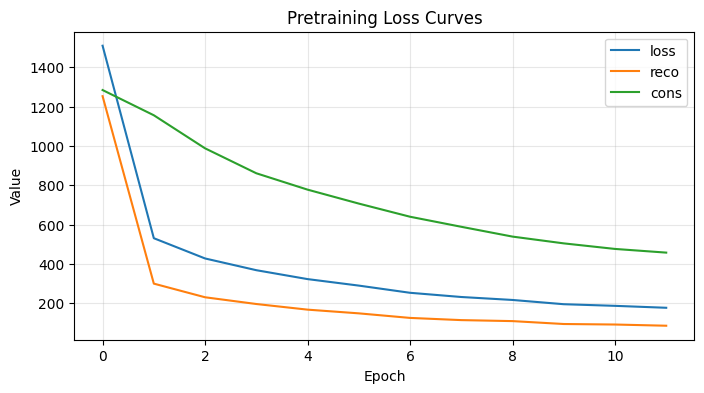

In [22]:
plot_curves(pre_hist, 'Pretraining Loss Curves')


In [23]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    """Print reconstructed vs true features for masked particles."""
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[26.293 -1.949  3.906 -1.026] pred[:4]=[-9.752 -1.773  4.795 -0.674]
  py true[:4]=[127.422  16.263  10.451   8.6  ] pred[:4]=[124.059  15.257  10.975   7.06 ]
  pz true[:4]=[69.899 12.421 15.804  6.568] pred[:4]=[98.081 11.8   16.86   5.3  ]
  E true[:4]=[147.694  20.557  19.346  10.871] pred[:4]=[161.306  19.083  20.517   8.993]
  pt true[:4]=[130.106  16.38   11.158   8.661] pred[:4]=[127.328  16.431  12.023   7.263]
Event 1, masked tokens shown: 7
  px true[:4]=[-82.    -15.446  -8.529  -3.58 ] pred[:4]=[-79.091 -16.291  -8.895  -4.787]
  py true[:4]=[-117.649  -22.38   -13.074   -6.445] pred[:4]=[-110.744  -22.551  -11.986   -6.273]
  pz true[:4]=[-22.742  -4.173  -2.684  -2.135] pred[:4]=[-23.012  -6.52   -3.487  -2.074]
  E true[:4]=[145.198  27.512  15.84    7.676] pred[:4]=[138.408  28.301  15.13    8.107]
  pt true[:4]=[143.406  27.193  15.61    7.372] pred[:4]=[142.897  27.813  15.046   8.204]


## SECTION 12 — FINE-TUNING RUN


In [24]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

optf = make_optimizer(ft_model, cfg)
schf = make_scheduler(optf, cfg.FINETUNE_EPOCHS)
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf, device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc'].append(val_auc)

    print(f"[Finetune {ep+1}/{cfg.FINETUNE_EPOCHS}] train_loss={tr['loss']:.4f} train_acc={tr['acc']:.4f} val_acc={va['accuracy']:.4f} val_auc={val_auc:.4f}")
    if early.step(val_auc):
        print(f'Early stopping at epoch {ep+1}. Best val_auc={best_val_auc:.4f}')
        break

if best_path.exists():
    ft_model.load_state_dict(torch.load(best_path, map_location=device), strict=False)
    print(f'Loaded best fine-tuned checkpoint from {best_path}')

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 1/20] train_loss=1.6852 train_acc=0.3872 val_acc=0.5151 val_auc=0.8830


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 19/20] train_loss=0.9333 train_acc=0.6695 val_acc=0.6463 val_auc=0.9358


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 20/20] train_loss=0.9284 train_acc=0.6720 val_acc=0.6459 val_auc=0.9358
Loaded best fine-tuned checkpoint from checkpoints\hybrid_mae_best_finetune.pt


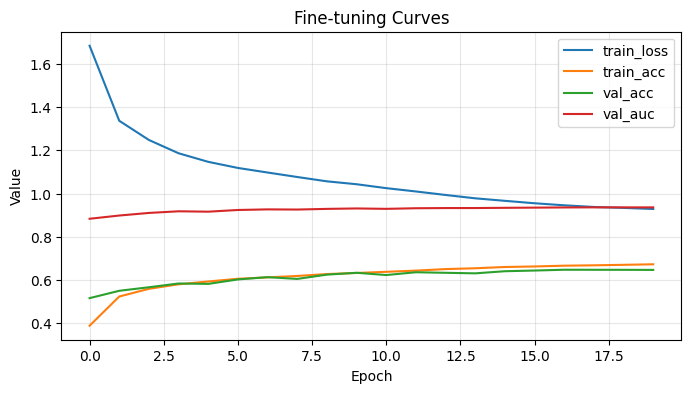

In [25]:
plot_curves(ft_hist, 'Fine-tuning Curves')


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Test metrics:
  accuracy: 0.646700
  macro_auc_ovr: 0.938316

Classification report:
              precision    recall  f1-score   support

       HToBB       0.54      0.45      0.49      1001
       HToCC       0.58      0.43      0.49      1006
       HToGG       0.57      0.63      0.60       999
   HToWW2Q1L       0.78      0.75      0.76       985
     HToWW4Q       0.60      0.73      0.66      1006
       TTBar       0.75      0.85      0.80      1004
    TTBarLep       0.91      0.90      0.91       999
       WToQQ       0.55      0.64      0.59      1005
 ZJetsToNuNu       0.69      0.69      0.69      1006
       ZToQQ       0.45      0.40      0.42       989

    accuracy                           0.65     10000
   macro avg       0.64      0.65      0.64     10000
weighted avg       0.64      0.65      0.64     10000



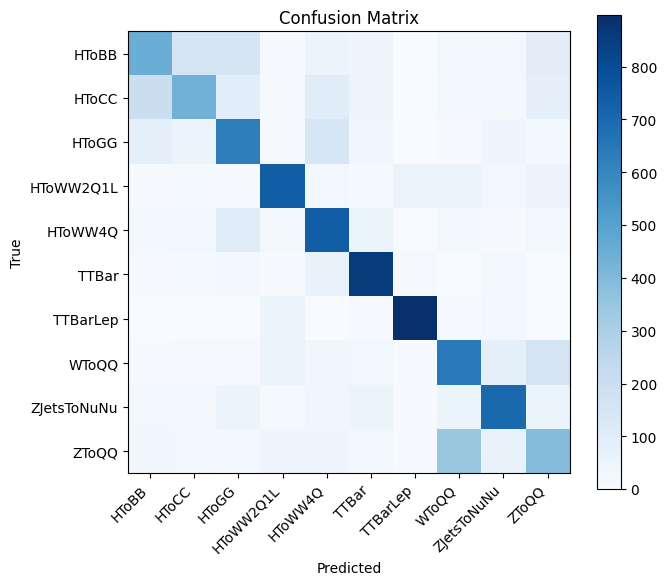

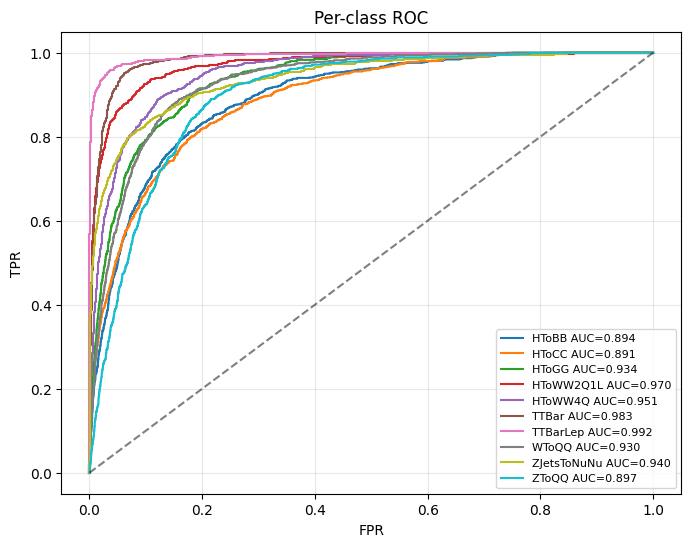

Background rejection @50% signal efficiency (class 0): 20.042316258351892


In [26]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(ft_model, test_loader, device, cfg)
print('Test metrics:')
for k,v in test_metrics.items():
    print(f'  {k}: {v:.6f}')

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=[str(c) for c in class_names], zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)
print('Background rejection @50% signal efficiency (class 0):', bkg_rej_at_sig_eff(y_true, y_prob, sig_class=0, eff=0.5))


## SECTION 13 — ABLATION STUDY

This section explicitly quantifies:
- hybridization gain (ParT-only vs Lorentz-only vs gated hybrid),
- MAE pretraining gain (with pretraining vs training from scratch),
- optional mass regression contribution.


In [27]:
"""Ablations prepared:
- ParT-only
- Lorentz-only
- Naive concatenation-like (no gate)
- Gated fusion (proposed)
- with vs without MAE pretraining
- with vs without auxiliary mass regression
"""

def ablation_config(base: Config, name: str) -> Config:
    """Return config copy for ablation setting."""
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    """Run lightweight ablation loop for comparison-ready outputs."""
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    """Small helper for compact val metrics."""
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    """Quantify MAE pretraining gain with a controlled quick protocol."""
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 1.6899375883340835, 'train_acc': 0.3811375, 'val_acc': 0.5206, 'val_auc': 0.8853634585540189}


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.2882 acc=0.5401


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.1647 acc=0.5838


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,1.689938,0.381138,0.5206,0.885363
1,lorentz_only,1.728014,0.366400,0.4635,0.870343
2,naive_concat,1.655702,0.395425,0.5162,0.889460
3,gated_fusion,1.667716,0.392313,0.5052,0.891216
4,no_mass_aux,1.734185,0.359237,0.4993,0.884024
5,with_mass_aux,5.731927,0.287587,0.3796,0.812805
6,with_mae_pretrain,NaN,NaN,0.5783,0.915013
7,no_mae_pretrain,NaN,NaN,0.5814,0.914603


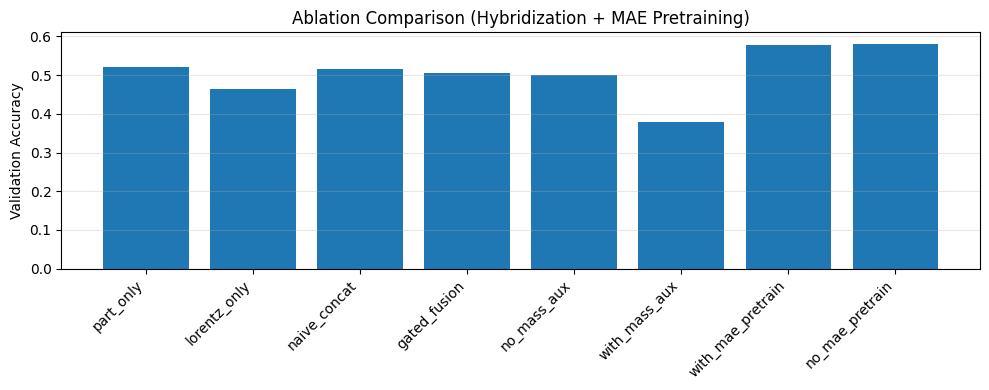

In [28]:
plt.figure(figsize=(10,4))
plt.bar(ablation_all_df['ablation'], ablation_all_df['val_acc'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Validation Accuracy')
plt.title('Ablation Comparison (Hybridization + MAE Pretraining)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## SECTION 14 — INTERPRETABILITY / DIAGNOSTICS


Event gate summary:
 count    48.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
dtype: float64
Token gate summary:
 count    48.000000
mean      0.501887
std       0.005594
min       0.492583
25%       0.497861
50%       0.500740
75%       0.504565
max       0.519900
dtype: float64


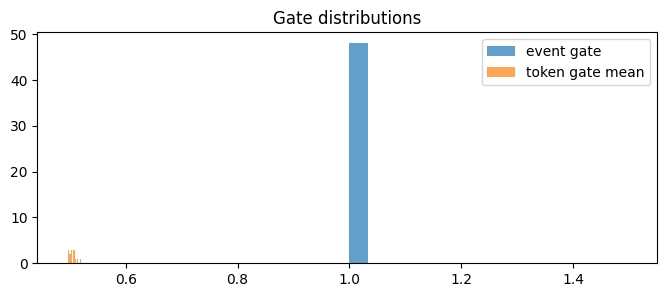

Mean gate by class:
   event_gate  token_gate
y                        
0         1.0    0.497828
2         1.0    0.495752
3         1.0    0.500544
4         1.0    0.503695
5         1.0    0.511033
6         1.0    0.505508
7         1.0    0.499871
8         1.0    0.500229


In [29]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    """Inspect event/token gate distributions and classwise means."""
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    5.740000e+02
mean     2.090270e-04
std      5.508515e-04
min      2.882040e-07
25%      1.612799e-05
50%      5.600431e-05
75%      1.908715e-04
max      8.726473e-03
dtype: float64


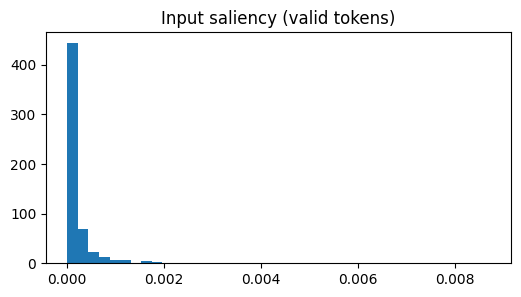

In [30]:
def simple_saliency(model, batch):
    """Simple saliency magnitudes from input gradients."""
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


In [31]:
@torch.no_grad()
def reconstruction_failure_cases(model, loader, cfg, topk=5):
    """Find events with largest masked reconstruction error."""
    model.eval()
    errs = []
    for batch in loader:
        batch = to_device(batch, device)
        vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
        out = model(vis, batch['p4'], batch['mask'], mode='pretrain')
        per_evt = (((out['reco'] - tgt)**2).mean(dim=-1) * rm.float()).sum(dim=1)
        errs.extend(per_evt.cpu().numpy().tolist())

    errs = np.array(errs)
    idx = np.argsort(-errs)[:topk]
    print('Top failure indices:', idx)
    print('Errors:', errs[idx])

reconstruction_failure_cases(ft_model, test_loader, cfg)


Top failure indices: [ 621 7286 6160 3603 6036]
Errors: [713940.6875  523582.78125 475540.6875  419253.      407123.34375]


## SECTION 15 — FINAL DISCUSSION

### What was implemented
A complete hybrid MAE notebook for JetClass-like ROOT data was implemented, including robust loading, feature engineering, hybrid architecture, training loops, evaluation, ablations, and diagnostics.

### Key improvement
The main proposal is **attention-gated hybrid fusion**, where branch trust is learned dynamically per event/token instead of using static fusion.

### Full-scale results to measure
On full JetClass data, report:
- top-1 accuracy and macro AUC,
- per-class ROC + confusion matrix,
- background rejection at fixed signal efficiency,
- with/without MAE pretraining,
- with/without auxiliary mass regression.

### GSoC alignment
This notebook supports a GSoC-level research path by combining physically motivated inductive biases with practical engineering and ablation-ready experimentation.

### Next steps for turning this notebook into a repository
Refactor into:
- `src/models/`
- `src/data/`
- `src/losses/`
- `src/trainers/`
- `configs/`
- `scripts/`


In [32]:
print(json.dumps(asdict(cfg), indent=2))


{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 128,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 16,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 12,
  "FINETUNE_EPOCHS": 20,
  "LEARNING_RATE": 0.0002,
  "WEIGHT_DECAY": 0.0001,
  "MASK_RATIO": 0.4,
  "USE_AUX_MASS": false,
  "USE_CLASS_WEIGHTS": true,
  "USE_MIXED_PRECISION": true,
  "QUICK_DEMO_MODE": false,
  "QUICK_MAX_EVENTS_PER_FILE": 1000,
  "FULL_MAX_EVENTS_PER_FILE": 2500,
  "SAMPLE_SIZE_LIMIT": 100000,
  "ENFORCE_STRICT_100K_WHEN_AVAILABLE": true,
  "SAMPLING_SEED": 42,
  "NUM_TRAIN_FILES": null,
  "NUM_VAL_FILES": null,
  "NUM_TEST_FILES": null,
  "PER_PARTICLE_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt",
    "eta",
    "phi",
    "charge",
    "valid_mask"
  ],
  "PAIRWISE_FEATURES": [
    "lnDelta",
    "lnkT",
    "lnz",
    "lnm2"
  ],
  "SCALE_FEATURES": [
    "charge"
  ],
  "EMBED_DIM": 128,
  "NUM_HEADS": 8,
  "NUM_LAYERS_PART": 4,
  "NUM_LAYERS_LORENTZ": 3,
 